In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install simpy

In [4]:
import simpy
import random
import statistics

def mm1_queue(env, service_rate, queue_lengths):
    while True:
        service_time = random.expovariate(service_rate)
        queue_lengths.append(service_time)
        yield env.timeout(service_time)

def run_simulation(arrival_rate, service_rate, sim_time):
    env = simpy.Environment()
    queue_lengths = []
    env.process(mm1_queue(env, service_rate, queue_lengths))
    env.run(until=sim_time)
    return statistics.mean(queue_lengths)

param = {
    "arrival_rate": random.uniform(0.1, 10),
    "service_rate": random.uniform(0.1, 10),
    "sim_time": random.randint(100, 500)
}

result = run_simulation(param["arrival_rate"], param["service_rate"], param["sim_time"])
print(result)

0.16618921448115082


In [5]:
import csv

results = []

for i in range(1000):
    arrival = random.uniform(0.1, 10)
    service = random.uniform(0.1, 10)
    sim_t = random.randint(100, 1000)

    avg_queue_len = run_simulation(arrival, service, sim_t)
    results.append([arrival, service, sim_t, avg_queue_len])

with open("sim_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["arrival_rate","service_rate","sim_time","avg_queue"])
    writer.writerows(results)
print("Simulations done!")

Simulations done!


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Load data
df = pd.read_csv("sim_results.csv")
X = df[["arrival_rate","service_rate","sim_time"]]
y = df["avg_queue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "MLP": MLPRegressor(max_iter=500)
}

metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    metrics.append([name, mse, r2])

eval_df = pd.DataFrame(metrics, columns=["Model","MSE","R2"])
print(eval_df.sort_values(by="R2", ascending=False))

              Model       MSE        R2
4  GradientBoosting  0.001656  0.995523
3      RandomForest  0.001811  0.995105
7      DecisionTree  0.003262  0.991182
8               MLP  0.162059  0.561950
1             Ridge  0.233192  0.369675
0            Linear  0.233201  0.369651
2             Lasso  0.307456  0.168938
6               KNN  0.379630 -0.026151
5               SVR  0.380562 -0.028672


/tmp/ipykernel_55/1173178307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Model", data=eval_df_sorted, palette="viridis", dodge=False, legend=False)
/tmp/ipykernel_55/1173178307.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MSE", y="Model", data=eval_df_sorted, palette="magma", dodge=False, legend=False)


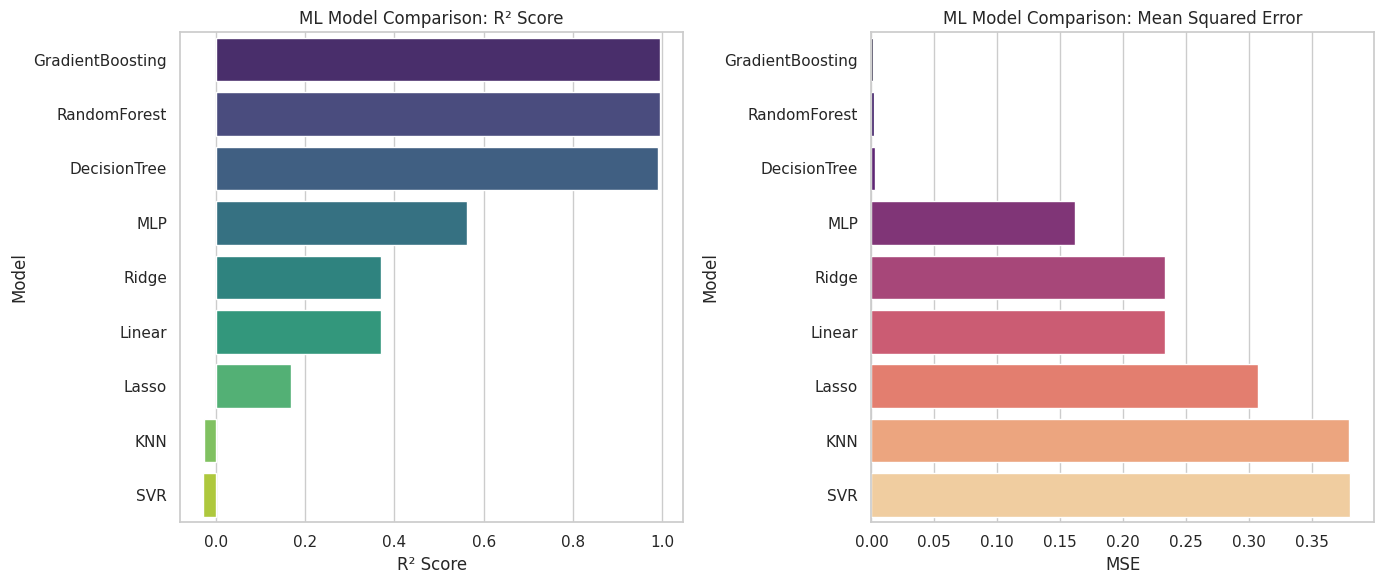

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(14,6))

# --- R2 Bar Chart ---
plt.subplot(1,2,1)
sns.barplot(x="R2", y="Model", data=eval_df_sorted, palette="viridis", dodge=False, legend=False)
plt.title("ML Model Comparison: R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

# --- MSE Bar Chart ---
plt.subplot(1,2,2)
sns.barplot(x="MSE", y="Model", data=eval_df_sorted, palette="magma", dodge=False, legend=False)
plt.title("ML Model Comparison: Mean Squared Error")
plt.xlabel("MSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()